In [1]:
import pandas as pd

df = pd.read_csv("../data/forestfires.csv")

df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [2]:
df.shape

(517, 13)

In [3]:
df.columns

Index(['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH',
       'wind', 'rain', 'area'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), str(2)
memory usage: 55.7 KB


In [5]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [6]:
df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

In [7]:
# A new column called fire_risk is created (which is our target variable). This column gets filled with 0 or 1 based on whether the burned area is greater than 0.
# area = 0 -> no fire -> FALSE.
# area > 0 -> fire occurred -> TRUE
# .astype(int) converts TRUE to 1 and FALSE to 0.

df["fire_risk"] = (df["area"] > 0).astype(int)

In [8]:
df[["area", "fire_risk"]].head(10)

,area,fire_risk
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0
5,0.0,0
6,0.0,0
7,0.0,0
8,0.0,0
9,0.0,0


In [37]:
# Input features
X = df[[
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "temp",
    "RH",
    "wind",
    "rain"
]]

# FFMC - Fine fuel moisture code, DMC - Duff moisture code, DC - Drought code, ISI - Initial spread index

# y is the target variable
y = df["fire_risk"]

In [38]:
print(X.head())

   FFMC   DMC     DC  ISI  temp  RH  wind  rain
0  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0
1  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0
2  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0
3  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2
4  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0


In [39]:
print(y.head())

0    0
1    0
2    0
3    0
4    0
Name: fire_risk, dtype: int64


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
print(X_train.shape)
print(X_test.shape)

(413, 8)
(104, 8)


In [42]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
# model is just a varaible that holds the empty random forest.
# Since I have added more input features, I am increasing the number of random forest trees to 300.
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

In [69]:
print(model)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)


In [70]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [71]:
# All the predictions are stored in the 'predictions' variable
predictions = model.predict(X_test)

In [72]:
print(predictions)

[0 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 0 0 0 1 0 0 0 0 0 1 1 0
 0 1 0 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [73]:
# Now we check the accuracy of my model. Importing accuracy tool...
from sklearn.metrics import accuracy_score

In [74]:
# Calculating accuracy
accuracy = accuracy_score(y_test, predictions)
print("Accuracy of the model: ", accuracy)

Accuracy of the model:  0.6153846153846154


In [75]:
# PREDICTIONS VS REALITY
# pd.DataFrame creates a table. The dictionary part tells pandas what columns to create.
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

print(comparison.head(20))

     Actual  Predicted
304       0          0
501       0          0
441       1          1
153       1          1
503       1          1
131       0          0
204       1          1
512       1          0
325       0          1
247       1          1
507       0          1
353       1          1
289       0          1
84        0          0
10        0          0
324       1          0
78        0          1
30        0          0
184       1          1
195       1          1


In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [77]:
# Creating a matrix
cm = confusion_matrix(y_test, predictions)

In [78]:
print(cm)

[[28 23]
 [17 36]]


In [79]:
# Building the graph setup
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

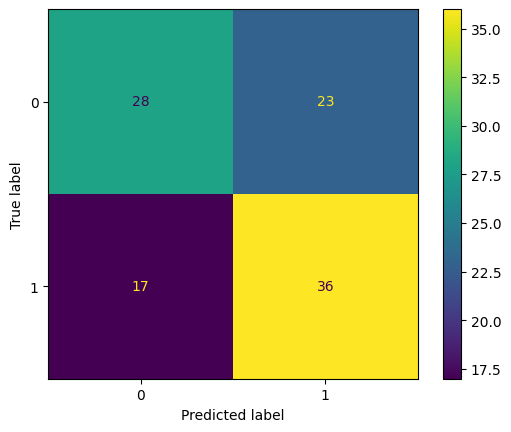

In [80]:
# Displaying the graph
disp.plot()

In [81]:
# Getting importance values
# model is my trained random forest.
# .feature_importances_ is an attribute of the trained model.

importance = model.feature_importances_
print(importance)

# The output four terms correspond to ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]

[0.12657189 0.14363618 0.13932045 0.11774981 0.17913159 0.16475836
 0.12138681 0.00744491]


In [82]:
feature_names = X.columns
for name, score in zip(feature_names, importance):
    print(name ,':', score)

# zip() pairs two lists together.

FFMC : 0.12657189232881438
DMC : 0.14363617881151572
DC : 0.13932045010316402
ISI : 0.11774981327041714
temp : 0.17913158910071386
RH : 0.1647583556928614
wind : 0.1213868131887903
rain : 0.00744490750372324


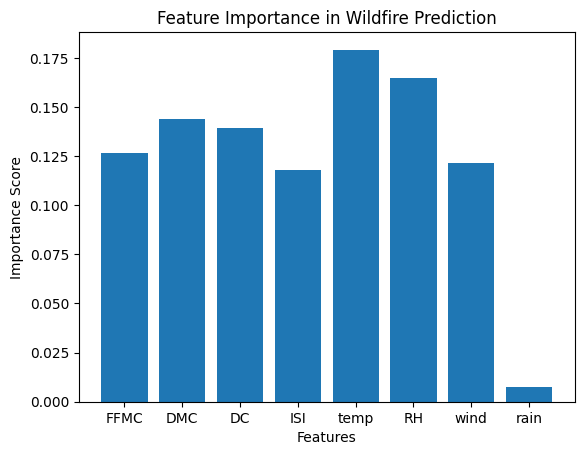

In [83]:
# Feature importance graph.
import matplotlib.pyplot as plt

plt.bar(feature_names, importance)

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance in Wildfire Prediction")

plt.show()

In [84]:
# This graph shows that temperature was the strongest wildfire predictor. 

In [85]:
# Manual custom prediction testing -
sample_data = pd.DataFrame(
    [[40, 20, 8, 0, 0, 12, 0, 0]],
    columns=["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]
)
# double brackets [[]] signify one complete row - 1 row, 4 columns
# 40 - temp, 20 - humidity, 8 - wind, 0 - rain

prediction = model.predict(sample_data)

print(prediction)

[0]


In [86]:
sample_data = pd.DataFrame(
    [[45, 10, 15, 0, 5, 0, 0, 0]],
    columns=["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]
)

prediction = model.predict(sample_data)
print(prediction)

[0]


In [87]:
sample_data = pd.DataFrame(
    [[50, 0, 20, 0, 0, 0, 0, 0]],
    columns=["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]
)

prediction = model.predict(sample_data)
print(prediction)

[0]


In [88]:
sample_data = pd.DataFrame(
    [[45, 1, 20, 0, 0, 0, 0, 0]],
    columns=["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]
)

prediction = model.predict(sample_data)
print(prediction)

[0]


In [89]:
# Classification report
from sklearn.metrics import classification_report

report = classification_report(y_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.62      0.55      0.58        51
           1       0.61      0.68      0.64        53

    accuracy                           0.62       104
   macro avg       0.62      0.61      0.61       104
weighted avg       0.62      0.62      0.61       104

